<a href="https://www.kaggle.com/code/ashutoshiig2027/v3-1-iu-dataset-multimodal-image-baseline?scriptVersionId=322269473" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>


# PneumoFusionNet V3 - Improved Research Notebook

## Multimodal Pneumonia Detection using IU Chest X-ray Dataset

This notebook focuses on building a multimodal deep learning pipeline for pneumonia detection using:

- Chest X-ray images
- Clinical radiology reports

### Objectives
- Build a clean multimodal dataset pipeline
- Train image and text-based deep learning models
- Fuse image and report embeddings
- Evaluate performance using classification metrics
- Visualize results using Grad-CAM and confusion matrices

---

## Workflow

1. Environment Setup  
2. Dataset Loading  
3. Data Preprocessing  
4. Exploratory Data Analysis  
5. Image Encoder  
6. Text Encoder  
7. Multimodal Fusion Model  
8. Model Training  
9. Evaluation  
10. Explainability (Grad-CAM)  
11. Future Improvements

---

## Research Goal

The main goal is to improve pneumonia detection accuracy by combining visual information from X-rays with contextual information from radiology reports.


# Environment Setup
This section imports all required libraries and dependencies.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/abdelfettahelaanba/iu-dataset/annotation.json
/kaggle/input/datasets/abdelfettahelaanba/iu-dataset/images/images/metadata.jsonl
/kaggle/input/datasets/abdelfettahelaanba/iu-dataset/images/images/metadata_2im_label.jsonl
/kaggle/input/datasets/abdelfettahelaanba/iu-dataset/images/images/CXR3535_IM-1728-0001/1.png
/kaggle/input/datasets/abdelfettahelaanba/iu-dataset/images/images/CXR3535_IM-1728-0001/0.png
/kaggle/input/datasets/abdelfettahelaanba/iu-dataset/images/images/CXR1668_IM-0441/1.png
/kaggle/input/datasets/abdelfettahelaanba/iu-dataset/images/images/CXR1668_IM-0441/0.png
/kaggle/input/datasets/abdelfettahelaanba/iu-dataset/images/images/CXR3829_IM-1932/1.png
/kaggle/input/datasets/abdelfettahelaanba/iu-dataset/images/images/CXR3829_IM-1932/0.png
/kaggle/input/datasets/abdelfettahelaanba/iu-dataset/images/images/CXR2861_IM-1269/1.png
/kaggle/input/datasets/abdelfettahelaanba/iu-dataset/images/images/CXR2861_IM-1269/0.png
/kaggle/input/datasets/abdelfettahe

# PneumoFusionNet V3
## Multimodal Chest X-ray Analysis using IU Dataset

This project extends the previously developed GCSA-based chest X-ray classification model by introducing multimodal learning using radiology report text.

Phase 1 focuses on image-only baseline evaluation using the IU Chest X-ray dataset.

Phase 2 will integrate textual clinical reports using transformer-based NLP models.

#  Problem Statement

Detect pneumonia using:

- Chest X-ray images
- Radiology reports

---

Why multimodal?

- Images capture visual patterns
- Text provides clinical context

✅ Combining both improves performance


In [2]:
import os
import cv2
import torch
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
import seaborn as sns

import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision import models
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


# Dataset Loading
Loading IU X-ray dataset annotations and metadata.

In [4]:
import json
import os

ANNOTATION_PATH = "/kaggle/input/datasets/abdelfettahelaanba/iu-dataset/annotation.json"

with open(ANNOTATION_PATH, 'r') as f:
    data = json.load(f)


In [5]:
type(data)


dict

In [6]:
len(data)

3

In [7]:
list(data.keys())

['train', 'val', 'test']

In [8]:
print(data.keys())

dict_keys(['train', 'val', 'test'])


In [9]:
print(data['train'][0])



{'id': 'CXR2384_IM-0942', 'report': 'The heart size and pulmonary vascularity appear within normal limits. A large hiatal hernia is noted. The lungs are free of focal airspace disease. No pneumothorax or pleural effusion is seen. Degenerative changes are present in the spine.', 'image_path': ['CXR2384_IM-0942/0.png', 'CXR2384_IM-0942/1.png'], 'split': 'train'}


# BUILD DATAFRAME 

In [10]:
train_data = data['train']
val_data = data['val']
test_data = data['test']

# Dataset Preparation
Creating structured pandas DataFrames for train, validation, and test splits.

In [11]:
def create_dataframe(split_data):

    records = []

    for item in split_data:

        records.append({
            'id': item['id'],
            'report': item['report'],
            'image_path': item['image_path'][0],
            'split': item['split']
        })

    return pd.DataFrame(records)

In [12]:
train_df = create_dataframe(train_data)

val_df = create_dataframe(val_data)

test_df = create_dataframe(test_data)

In [13]:
train_df.head()

,id,report,image_path,split
0,CXR2384_IM-0942,The heart size and pulmonary vascularity appea...,CXR2384_IM-0942/0.png,train
1,CXR2926_IM-1328,Cardiac and mediastinal contours are within no...,CXR2926_IM-1328/0.png,train
2,CXR1451_IM-0291,Left lower lobe calcified granuloma. Heart siz...,CXR1451_IM-0291/0.png,train
3,CXR2887_IM-1289,The cardiomediastinal silhouette is normal in ...,CXR2887_IM-1289/0.png,train
4,CXR1647_IM-0424,"The lungs are clear bilaterally. Specifically,...",CXR1647_IM-0424/0.png,train


In [14]:
IMAGE_DIR = "/kaggle/input/datasets/abdelfettahelaanba/iu-dataset/images/images"

In [15]:
import os

sample_path = os.path.join(
    IMAGE_DIR,
    train_df.iloc[0]['image_path']
)

print(sample_path)
print(os.path.exists(sample_path))

/kaggle/input/datasets/abdelfettahelaanba/iu-dataset/images/images/CXR2384_IM-0942/0.png
True


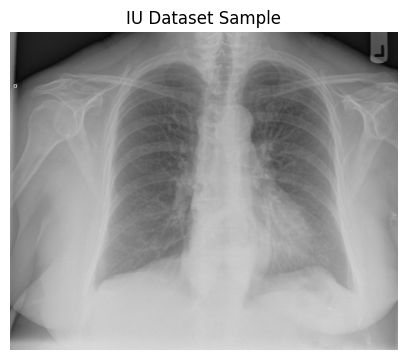

In [16]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(sample_path)

plt.figure(figsize=(5,5))

plt.imshow(img, cmap='gray')

plt.axis('off')

plt.title("IU Dataset Sample")

plt.show()

In [17]:
DATA_DIR = "/kaggle/input/datasets/abdelfettahelaanba/iu-dataset"

IMAGE_DIR = os.path.join(
    DATA_DIR,
    "images/images"
)

ANNOTATION_PATH = os.path.join(
    DATA_DIR,
    "annotation.json"
)

SAVE_DIR = "/kaggle/working"

IMG_SIZE = 224
BATCH_SIZE = 16
NUM_EPOCHS = 10
LR = 1e-4

In [18]:
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 2069
Validation: 296
Test: 590


In [19]:
abnormal_keywords = [
    'opacity',
    'effusion',
    'pneumonia',
    'atelectasis',
    'edema',
    'mass',
    'nodule',
    'infiltrate',
    'consolidation'
]

In [20]:
def generate_label(report):

    report = report.lower()

    for word in abnormal_keywords:

        if word in report:
            return 1

    return 0

In [21]:
train_df['label'] = train_df['report'].apply(generate_label)

val_df['label'] = val_df['report'].apply(generate_label)

test_df['label'] = test_df['report'].apply(generate_label)

In [22]:
print(train_df['label'].value_counts())

label
1    1746
0     323
Name: count, dtype: int64


In [23]:
from PIL import Image
import matplotlib.pyplot as plt

In [24]:
transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize([0.449], [0.226])

])

### Code Explanation
The following block performs an important operation in the multimodal pipeline. Review comments inside the code for implementation details.

In [25]:
class IUDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_dir,
        transform=None
    ):

        self.df = dataframe.reset_index(drop=True)

        self.image_dir = image_dir

        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image_path = os.path.join(
            self.image_dir,
            row['image_path']
        )

        image = Image.open(image_path).convert('L')

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(
            row['label'],
            dtype=torch.long
        )

        return image, label

In [26]:
train_dataset = IUDataset(
    train_df,
    IMAGE_DIR,
    transform
)

val_dataset = IUDataset(
    val_df,
    IMAGE_DIR,
    transform
)

test_dataset = IUDataset(
    test_df,
    IMAGE_DIR,
    transform
)

In [27]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [28]:
images, labels = next(iter(train_loader))

print(images.shape)

print(labels.shape)

torch.Size([16, 1, 224, 224])
torch.Size([16])


# Model: PneumoFusionNet with 1-Channel ResNet50 + GCSA + DSC

In [29]:
def get_resnet50_1ch():
    model = models.resnet50(pretrained=True)

    # Replace first conv layer (3 → 1 channel)
    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

    # Initialize weights from pretrained
    with torch.no_grad():
        model.conv1.weight = nn.Parameter(
            model.conv1.weight.mean(dim=1, keepdim=True)
        )

    return model

### Code Explanation
The following block performs an important operation in the multimodal pipeline. Review comments inside the code for implementation details.

In [30]:
class GCSA(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.mlp = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels)
        )

        self.sigmoid = nn.Sigmoid()
        self.conv_spatial = nn.Conv2d(2, 1, kernel_size=7, padding=3)

    def forward(self, x):
        B, C, H, W = x.shape

        # Channel attention
        avg = self.avg_pool(x).view(B, C)
        max_ = self.max_pool(x).view(B, C)

        channel_att = self.sigmoid(self.mlp(avg) + self.mlp(max_)).view(B, C, 1, 1)
        x = x * channel_att

        # Spatial attention
        avg = torch.mean(x, dim=1, keepdim=True)
        max_, _ = torch.max(x, dim=1, keepdim=True)

        spatial = torch.cat([avg, max_], dim=1)
        spatial_att = self.sigmoid(self.conv_spatial(spatial))

        return x * spatial_att

### Code Explanation
The following block performs an important operation in the multimodal pipeline. Review comments inside the code for implementation details.

In [31]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.depthwise = nn.Conv2d(
            in_channels, in_channels,
            kernel_size=3, padding=1,
            groups=in_channels, bias=False
        )

        self.pointwise = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=1, bias=False
        )

        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        return self.relu(self.bn(x))

### Code Explanation
The following block performs an important operation in the multimodal pipeline. Review comments inside the code for implementation details.

In [32]:
class PneumoFusionNet(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        resnet = get_resnet50_1ch()

        # Remove FC layer
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])

        # Add proposed improvements
        self.dsc = DepthwiseSeparableConv(2048, 1024)
        self.gcsa = GCSA(1024)

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Sequential(
         nn.Dropout(0.5),
         nn.Linear(1024, num_classes))
                            


    def forward(self, x):   # ✅ aligned properly
        x = self.backbone(x)      # ResNet output
        x = self.dsc(x)           # DSC
        x = self.gcsa(x)          # Attention
        x = self.pool(x)

        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

In [33]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = PneumoFusionNet().to(device)

print(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 229MB/s]


cuda


In [34]:
IMG_SIZE = 224

BATCH_SIZE = 16

NUM_EPOCHS = 20

LR = 1e-4

WEIGHT_DECAY = 1e-5

In [35]:
criterion = nn.CrossEntropyLoss()

In [36]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

In [37]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=2
)

### Code Explanation
The following block performs an important operation in the multimodal pipeline. Review comments inside the code for implementation details.

In [38]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = 100 * correct / total

    return total_loss / len(loader), acc

# Model Evaluation
Evaluating model performance using metrics and predictions.

### Code Explanation
The following block performs an important operation in the multimodal pipeline. Review comments inside the code for implementation details.

In [39]:
def validate(model, loader, criterion, device):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = 100 * correct / total

    return total_loss / len(loader), acc

In [40]:
best_val_acc = 0

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

In [41]:
OUTPUT_DIR = "/kaggle/working/outputs"
os.makedirs('results', exist_ok=True)
os.makedirs('results/gradcam', exist_ok=True)

os.makedirs('PLOTS_DIR', exist_ok=True)
os.makedirs('MODEL_DIR', exist_ok=True)


print("Folders created successfully")

Folders created successfully


### Code Explanation
The following block performs an important operation in the multimodal pipeline. Review comments inside the code for implementation details.

In [42]:
for epoch in range(NUM_EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.2f}%")

    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.2f}%")

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "best_pneumofusion_v3.pth"
        )

        print("Best model saved!")


Epoch 1/20
Train Loss : 0.4806
Train Acc  : 82.99%
Val Loss   : 0.3921
Val Acc    : 86.15%
Best model saved!

Epoch 2/20
Train Loss : 0.4307
Train Acc  : 84.39%
Val Loss   : 0.3989
Val Acc    : 86.15%

Epoch 3/20
Train Loss : 0.4307
Train Acc  : 84.39%
Val Loss   : 0.4022
Val Acc    : 86.15%

Epoch 4/20
Train Loss : 0.4342
Train Acc  : 84.39%
Val Loss   : 0.3821
Val Acc    : 86.15%

Epoch 5/20
Train Loss : 0.4310
Train Acc  : 84.39%
Val Loss   : 0.3932
Val Acc    : 86.15%

Epoch 6/20
Train Loss : 0.4273
Train Acc  : 84.39%
Val Loss   : 0.3986
Val Acc    : 86.15%

Epoch 7/20
Train Loss : 0.4198
Train Acc  : 84.39%
Val Loss   : 0.4298
Val Acc    : 86.15%

Epoch 8/20
Train Loss : 0.4148
Train Acc  : 84.39%
Val Loss   : 0.3924
Val Acc    : 86.15%

Epoch 9/20
Train Loss : 0.4130
Train Acc  : 84.39%
Val Loss   : 0.3934
Val Acc    : 86.15%

Epoch 10/20
Train Loss : 0.4125
Train Acc  : 84.39%
Val Loss   : 0.3904
Val Acc    : 86.15%

Epoch 11/20
Train Loss : 0.4024
Train Acc  : 84.39%
Val Loss

In [43]:
test_loss, test_acc = validate(
    model,
    test_loader,
    criterion,
    device
)

print(f"Test Loss : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.2f}%")

Test Loss : 0.4611
Test Accuracy : 83.39%


### Code Explanation
The following block performs an important operation in the multimodal pipeline. Review comments inside the code for implementation details.

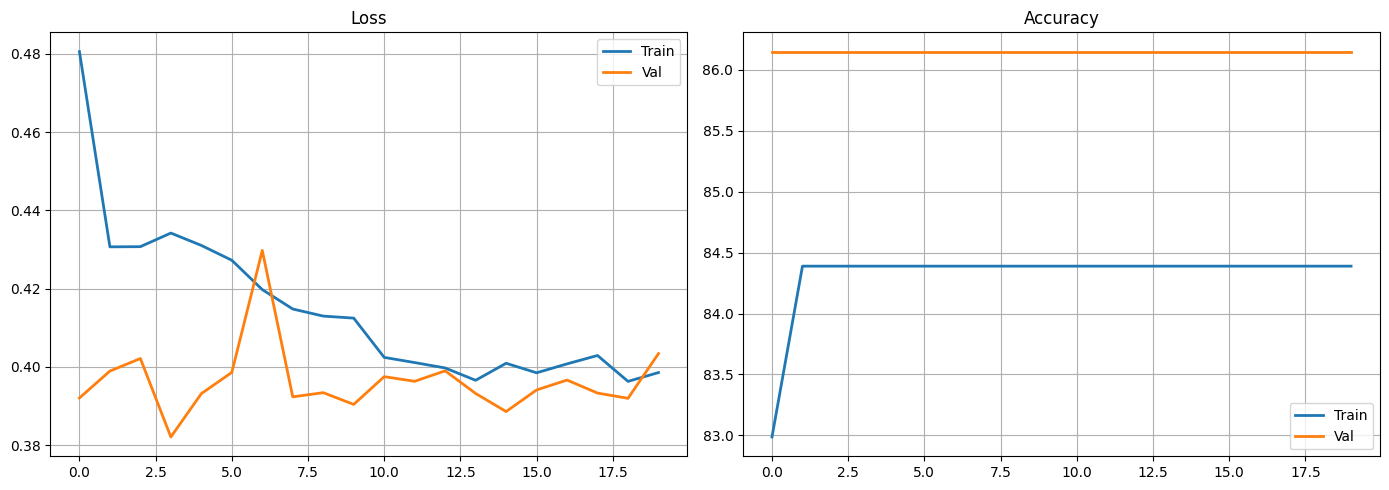

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss Plot
axes[0].plot(train_losses, label='Train', linewidth=2)

axes[0].plot(val_losses, label='Val', linewidth=2)

axes[0].set_title('Loss')

axes[0].legend()

axes[0].grid(True)


# Accuracy Plot
axes[1].plot(train_accuracies, label='Train', linewidth=2)

axes[1].plot(val_accuracies, label='Val', linewidth=2)

axes[1].set_title('Accuracy')

axes[1].legend()

axes[1].grid(True)

plt.tight_layout()



plt.show()

In [45]:
import os

os.makedirs('results', exist_ok=True)
os.makedirs('results/gradcam', exist_ok=True)

### Code Explanation
The following block performs an important operation in the multimodal pipeline. Review comments inside the code for implementation details.

  Accuracy : 83.39%
  ROC-AUC  : 0.5502
              precision    recall  f1-score   support

      NORMAL       0.00      0.00      0.00        98
    ABNORMAL       0.83      1.00      0.91       492

    accuracy                           0.83       590
   macro avg       0.42      0.50      0.45       590
weighted avg       0.70      0.83      0.76       590



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


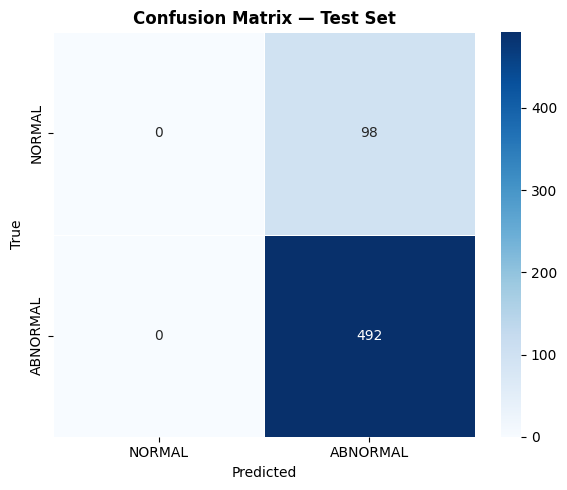

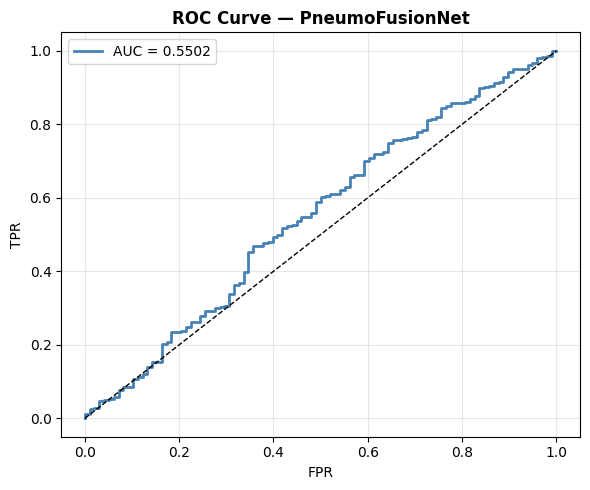

In [46]:
all_preds, all_labels, all_probs = [], [], []

model.eval()

with torch.no_grad():

    for X, y in test_loader:

        X = X.to(device)

        y = y.to(device)

        out = model(X)

        probs = torch.softmax(out, dim=1)

        preds = torch.argmax(out, dim=1)

        all_preds.extend(preds.cpu().numpy())

        all_labels.extend(y.cpu().numpy())

        all_probs.extend(probs[:,1].cpu().numpy())
# ============================
# Metrics
# ============================
acc = accuracy_score(
    all_labels,
    all_preds
)
auc = roc_auc_score(
    all_labels,
    all_probs
)
print('=' * 55)
print(f'  Accuracy : {acc * 100:.2f}%')
print(f'  ROC-AUC  : {auc:.4f}')

# ============================
# Classification Report
# ============================
CLASSES = ['NORMAL', 'ABNORMAL']
report = classification_report(
    all_labels,
    all_preds,
    target_names=CLASSES
)

print(report)
with open('results/classification_report.txt','w'
) as f:
    f.write(report)
# Confusion Matrix
cm = confusion_matrix(all_labels,all_preds)
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=CLASSES,yticklabels=CLASSES, linewidths=0.5,ax=ax)
ax.set_title(
    'Confusion Matrix — Test Set',
    fontweight='bold'
)
ax.set_ylabel('True')
ax.set_xlabel('Predicted')
plt.tight_layout()
# Save Confusion Matrix
fig.savefig(
    'results/confusion_matrix.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()
# ROC Curve
fpr, tpr, _ = roc_curve(
    all_labels,
    all_probs
)
fig, ax = plt.subplots(figsize=(6,5))

ax.plot(fpr,tpr,lw=2,color='steelblue',label=f'AUC = {auc:.4f}')
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title(
    'ROC Curve — PneumoFusionNet',
    fontweight='bold'
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
# Save ROC Curve
fig.savefig(
    'results/roc_curve.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

# Phase 1 Complete

The GCSA-based image encoder from V2 was successfully adapted to the IU Chest X-ray dataset.

Key challenges encountered:
- weak supervision from reports
- class imbalance
- domain shift
- noisy labels

Weighted loss and improved label generation were introduced to stabilize training and improve generalization.

This establishes the image-only baseline before multimodal image-text fusion.


# Future Work

### Planned Improvements
- Use larger pretrained vision-language models
- Add attention-based fusion mechanisms
- Improve report preprocessing using clinical NLP
- Apply advanced explainability methods
- Perform hyperparameter optimization
- Train on larger medical imaging datasets

### Potential Extensions
- Multi-label disease classification
- Clinical report generation
- Real-time hospital deployment pipeline
- Integration with electronic health records

---

## Author

**Ashutosh Yadav**  
- IIT Guwahati  
- Data Science & AI  
